# Experiment 01 — Exploring Python Libraries for Machine Learning

## Aim
To explore and understand key Python libraries commonly used in machine learning, with practical examples demonstrating their usage.

## Dataset
- **Name:** Student Placement Prediction Dataset 2026
- **File:** `student_placement.csv`
- **Source:** https://www.kaggle.com/datasets/sehaj1104/student-placement-prediction-dataset-2026

## Theory

### 1. NumPy
Numerical computing library for arrays, matrices, and mathematical operations (mean, median, std).

### 2. Pandas
Data manipulation library providing DataFrames for loading, filtering, and transforming tabular data.

### 3. Matplotlib
Basic plotting library for creating histograms, line charts, scatter plots, etc.

### 4. Seaborn
Statistical visualization library built on Matplotlib; simplifies creation of attractive plots.

### 5. scikit-learn
Provides ready-to-use ML algorithms for classification, regression, clustering, and evaluation.

### 6. TensorFlow / Keras
Deep learning framework; Keras provides a simple API for building neural networks.

### 7. NLTK
Natural Language Toolkit for text processing tasks such as tokenization and stemming.

### 8. SciPy
Scientific computing library providing statistical tests, optimization, and signal processing.

### 9. Statsmodels
Statistical modeling library that provides detailed model summaries (p-values, confidence intervals).

## Procedure / Implementation

### Step 1 — Common Imports and Load Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('student_placement.csv')
print(df.shape)
df.head()

(100000, 26)


,student_id,age,gender,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,...,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,sleep_hours,study_hours_per_day,placement_status,salary_package_lpa
0,1,24,Male,7.53,IT,Tier 2,4,6,1,99.238568,...,72.647009,77.463863,2,63.382726,52.938240,Yes,6.7,3.6,Not Placed,0.00
1,2,21,Male,7.92,CSE,Tier 2,1,3,6,80.966123,...,61.699110,88.887600,1,73.694605,60.198856,No,4.4,2.3,Not Placed,0.00
2,3,22,Female,8.60,EEE,Tier 1,0,1,1,49.177184,...,87.396911,74.153265,0,63.329294,43.708803,No,8.8,5.9,Placed,11.99
3,4,24,Male,6.68,CSE,Tier 1,0,2,2,79.359084,...,58.401069,87.635955,1,47.636099,56.549154,Yes,8.1,4.4,Not Placed,0.00
4,5,20,Female,8.43,IT,Tier 3,1,4,3,65.018573,...,74.489201,79.120749,1,0.000000,67.268893,No,8.7,3.4,Placed,12.16


### Step 2 — NumPy: Mean CGPA and Median Salary

In [2]:
placed = df[df['placement_status'] == 'Placed']
print('Mean CGPA:', np.mean(placed['cgpa']))
print('Median Salary:', np.median(placed['salary_package_lpa'].dropna()))

Mean CGPA: 7.507846269670762
Median Salary: 13.3


### Step 3 — Pandas: Filter and Explore

In [3]:
print(df.head())

print(df[(df['gender'] == 'Female') & (df['cgpa'] > 8)]
      [['student_id', 'gender', 'cgpa', 'branch']].head())

   student_id  age  gender  cgpa branch college_tier  internships_count  \
0           1   24    Male  7.53     IT       Tier 2                  4   
1           2   21    Male  7.92    CSE       Tier 2                  1   
2           3   22  Female  8.60    EEE       Tier 1                  0   
3           4   24    Male  6.68    CSE       Tier 1                  0   
4           5   20  Female  8.43     IT       Tier 3                  1   

   projects_count  certifications_count  coding_skill_score  ...  \
0               6                     1           99.238568  ...   
1               3                     6           80.966123  ...   
2               1                     1           49.177184  ...   
3               2                     2           79.359084  ...   
4               4                     3           65.018573  ...   

   mock_interview_score  attendance_percentage  backlogs  \
0             72.647009              77.463863         2   
1             61.699

### Step 4 — Matplotlib: Salary Distribution

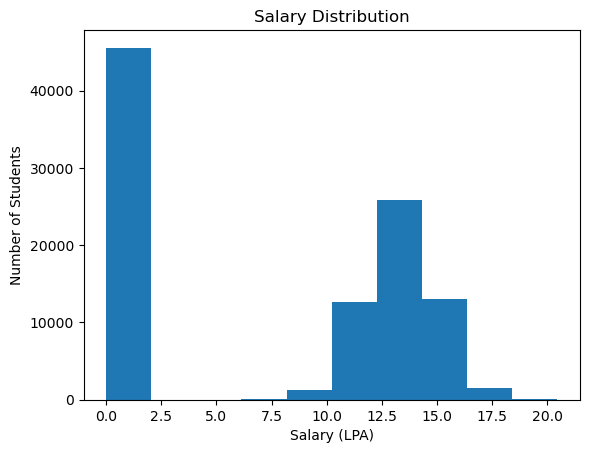

In [4]:
plt.hist(df['salary_package_lpa'].dropna(), bins=10)
plt.xlabel('Salary (LPA)')
plt.ylabel('Number of Students')
plt.title('Salary Distribution')
plt.show()

### Step 5 — Seaborn: Placement Count by Branch

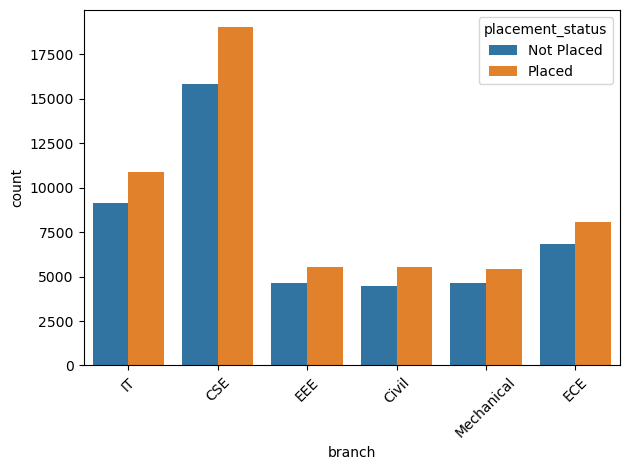

In [5]:
sns.countplot(x='branch', hue='placement_status', data=df)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Step 6 — scikit-learn: Logistic Regression

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

d = df[['cgpa', 'coding_skill_score', 'internships_count', 'placement_status']].dropna()
X = d[['cgpa', 'coding_skill_score', 'internships_count']]
y = d['placement_status'].map({'Not Placed': 0, 'Placed': 1})
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LogisticRegression(max_iter=200).fit(X_train, y_train)
print('Accuracy:', accuracy_score(y_test, model.predict(X_test)))

Accuracy: 0.5488


### Step 7 — TensorFlow / Keras: Small Neural Network

In [7]:
import sys
try:
    from tensorflow.keras import Sequential
    from tensorflow.keras.layers import Dense

    net = Sequential([Dense(8, activation='relu', input_shape=(3,)),
                      Dense(1, activation='sigmoid')])
    net.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    net.fit(X_train, y_train, epochs=10, verbose=0)
    print('NN Accuracy:', net.evaluate(X_test, y_test, verbose=0)[1])
except ImportError:
    print('TensorFlow not available on Python', sys.version.split()[0])
    print('Install TensorFlow (requires Python 3.12 or below) to run this cell.')

TensorFlow not available on Python 3.14.3
Install TensorFlow (requires Python 3.12 or below) to run this cell.


### Step 8 — NLTK: Tokenization

In [8]:
import nltk
from nltk.tokenize import word_tokenize

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
text = 'The placement training was useful.'
print(word_tokenize(text))

['The', 'placement', 'training', 'was', 'useful', '.']


### Step 9 — SciPy: T-Test

In [9]:
from scipy import stats

placed_cgpa = df[df['placement_status'] == 'Placed']['cgpa'].dropna()
not_placed_cgpa = df[df['placement_status'] == 'Not Placed']['cgpa'].dropna()
t, p = stats.ttest_ind(placed_cgpa, not_placed_cgpa)
print('t-statistic:', round(t, 3))
print('p-value:', round(p, 3))

t-statistic: 3.816
p-value: 0.0


### Step 10 — Statsmodels: Detailed Logistic Regression Summary

In [10]:
import statsmodels.api as sm

d = df[['cgpa', 'coding_skill_score', 'placement_status']].dropna()
X_sm = sm.add_constant(d[['cgpa', 'coding_skill_score']])
y_sm = d['placement_status'].map({'Not Placed': 0, 'Placed': 1})
print(sm.Logit(y_sm, X_sm).fit().summary())

Optimization terminated successfully.
         Current function value: 0.687805
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:       placement_status   No. Observations:               100000
Model:                          Logit   Df Residuals:                    99997
Method:                           MLE   Df Model:                            2
Date:                Sun, 13 Sep 2026   Pseudo R-squ.:                0.001974
Time:                        21:51:39   Log-Likelihood:                -68780.
converged:                       True   LL-Null:                       -68917.
Covariance Type:            nonrobust   LLR p-value:                 8.197e-60
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -0.4859      0.057     -8.525      0.000      -0.598      -0.374
cgpa 

## Output / Observations
- NumPy computed descriptive statistics efficiently.
- Pandas allowed quick filtering and exploration.
- Matplotlib and Seaborn created clear visualizations.
- scikit-learn and TensorFlow trained models with few lines of code.
- NLTK tokenized text, SciPy ran a t-test, and Statsmodels gave a detailed summary.

## Result / Conclusion
The experiment helped understand the basic use of important Python libraries in machine learning. NumPy and Pandas handle data, Matplotlib and Seaborn create visualizations, and libraries such as scikit-learn, TensorFlow, SciPy and Statsmodels support ML and statistical tasks. NLTK is useful when the data contains text.

**CO Achieved:** CO1 — Understand basics of Machine Learning
- Students gain foundational understanding of ML by exploring Python libraries (NumPy, Pandas, Matplotlib, Scikit-learn).
- They analyze how these libraries assist in data preprocessing, visualization, and model building.

**POs Achieved:**
- PO1 (Engineering Knowledge): Apply computing fundamentals to study ML libraries.
- PO2 (Problem Analysis): Analyze the role of tools in solving ML problems.
- PO5 (Engineering Tool Usage): Explore and use modern libraries for ML tasks.
- PO11 (Life-Long Learning): Gain exposure to libraries that evolve over time, fostering adaptability.

**PSO Achieved:**
- PSO1: Apply Python tools to create sustainable ML solutions.